In [1]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

import meshio
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go

from sklearn.neighbors import kneighbors_graph
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.spatial.distance import cdist

from sklearn.metrics import mean_squared_error
from sklearn import datasets, manifold
from sklearn.model_selection import train_test_split

import os

import time



In [2]:
# Dragon Mesh
def load_dragon_mesh(mesh_file):
    """Load dragon mesh using meshio instead of Firedrake"""
    mesh = meshio.read(mesh_file)
    
    # Extract vertices and faces
    vertices_orig = mesh.points

    # Swapping columns 1 and 2
    vertices = vertices_orig[:, [0, 2, 1]]
    
    cells = mesh.cells_dict.get('triangle', mesh.cells_dict.get('tetra', None))
    
    if cells is None:
        # Try other cell types
        for cell_type, cell_data in mesh.cells_dict.items():
            if cell_type in ['triangle', 'tetra', 'quad']:
                cells = cell_data
                break
    
    return vertices, cells

def construct_mesh_graph_manual(vertices, faces):
    """Construct NetworkX graph from mesh vertices and faces"""
    G = nx.Graph()
    
    # Add all vertices
    for i in range(len(vertices)):
        G.add_node(i)
    
    # Add edges from faces/cells
    for face in faces:
        # For triangular faces, add edges between all pairs
        for i in range(len(face)):
            for j in range(i+1, len(face)):
                v1, v2 = face[i], face[j]
                
                # Calculate Euclidean distance as weight (approximates geodesic)
                if not G.has_edge(v1, v2):
                    dist = np.linalg.norm(vertices[v1] - vertices[v2])
                    G.add_edge(v1, v2, weight=dist)
    
    return G


def construct_ground_truth_manual(vertices, faces, snout_vertex=7):
    """Reproduce the ground truth function using snout as source"""
    import networkx as nx
    
    # Construct the mesh graph
    mesh_graph = construct_mesh_graph_manual(vertices, faces)
    
    # Compute shortest path lengths from snout vertex instead of vertex 0
    geodesics = nx.shortest_path_length(mesh_graph, source=snout_vertex, weight='weight')
    
    N = len(vertices)  # Number of vertices
    
    ground_truth = np.zeros((N))
    period = 2*np.pi / 0.3 * 2  # Same formula as original
    
    for i in range(N):
        ground_truth[i] = 2 * np.sin(geodesics.get(i, 0) * period + 0.3)
    
    return ground_truth

# Load the dragon mesh (you need both vertices and faces)
vertices, faces = load_dragon_mesh('dragon_connected.msh')

# Construct the ground truth
ground_truth = construct_ground_truth_manual(vertices, faces)

# Extracting the subset of original points from the mesh to be used subsequently

In [3]:
indices_orig_train = np.array([3316, 10960, 24947, 33498, 33513, 34844, 35740, 35830, 36026,
         36654, 36727, 37597, 39066, 39886, 40050, 41165, 41387, 41430,
         42420, 43012, 43383, 45296, 45796, 47431, 48346, 48779, 49033,
         49127, 50374, 50878, 51132, 51168, 51175, 55643, 55863,
         56414, 56568, 56933, 57130, 57168, 57536, 60028, 61432, 61915,
         62936, 63657, 64280, 64542, 75551, 87643, 95423])

total_points = 3000

# Step 2: Take additional random points (excluding the training points)
np.random.seed(42)
available_indices = np.setdiff1d(np.arange(len(vertices)), indices_orig_train)
additional_indices = np.random.choice(available_indices, size=total_points-len(indices_orig_train), replace=False)

# Step 3: Combine to get 1000 total points
subset_indices = np.concatenate([indices_orig_train, additional_indices])

X = vertices[subset_indices]
y = ground_truth[subset_indices]

print("X shape:", X.shape)  # (1000, 3)
print("y shape:", y.shape)  # (1000,)

# Create train and test indices for the subset
n_train = len(indices_orig_train)
indices_train = np.arange(n_train)                    # [0, 1, 2, ..., 50]
indices_test = np.arange(n_train, total_points)       # [51, 52, 53, ..., 999]

# Extract training and test data using indices
x_train = X[indices_train]        # Training coordinates
y_train = y[indices_train]        # Training values
x_test = X[indices_test]          # Test coordinates  
y_test = y[indices_test]          # Test values

print("indices_train:", indices_train.shape, "range:", indices_train[0], "to", indices_train[-1])
print("indices_test:", indices_test.shape, "range:", indices_test[0], "to", indices_test[-1])
print("x_train shape: ", x_train.shape)  # (51, 3)
print("y_train shape: ", y_train.shape)  # (51,)
print("x_test shape: ", x_test.shape)    # (949, 3)
print("y_test shape: ", y_test.shape)    # (949,)
print("Total: ", x_train.shape[0] + x_test.shape[0])  # total_points

X shape: (3000, 3)
y shape: (3000,)
indices_train: (51,) range: 0 to 50
indices_test: (2949,) range: 51 to 2999
x_train shape:  (51, 3)
y_train shape:  (51,)
x_test shape:  (2949, 3)
y_test shape:  (2949,)
Total:  3000


In [4]:
# All points, shape: (100179, 3)

fig = go.Figure(data=[go.Scatter3d(
    x=X[:,0],y=X[:,1],z=X[:,2], mode='markers', marker=dict( size=5, color=y, colorscale='plasma',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()


In [5]:
snout_vertex = 7

# Full visualization with visible training points
fig = go.Figure(data=[
    # Original scatter plot (you can uncomment this)
    go.Scatter3d(
        x=X[:,0], y=X[:,1], z=X[:,2], 
        mode='markers', 
        marker=dict(size=5, color=y, colorscale='plasma', opacity=0.8),
        name='Ground Truth'
    ),
    # Red point for snout vertex
    go.Scatter3d(
        x=[vertices[snout_vertex, 0]], 
        y=[vertices[snout_vertex, 1]], 
        z=[vertices[snout_vertex, 2]],
        mode='markers',
        marker=dict(size=25, color='red'),
        name='Snout Vertex'
    ),
    # Black training points - LARGE with white outline for visibility
    go.Scatter3d(
        x=X[indices_train, 0], 
        y=X[indices_train, 1], 
        z=X[indices_train, 2],
        mode='markers',
        marker=dict(
            size=10, 
            color='black', 
            line=dict(width=3, color='white'),  # White outline makes them pop
            symbol='diamond'
        ),
        name='Training Points (51)'
    )
])

fig.update_layout(
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600, 
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

In [6]:
# Sampled points, shape: (N, 3)
fig = go.Figure(data=[go.Scatter3d(
    x=x_train[:,0],y=x_train[:,1],z=x_train[:,2], mode='markers', marker=dict( size=5, color=y_train, colorscale='plasma',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()


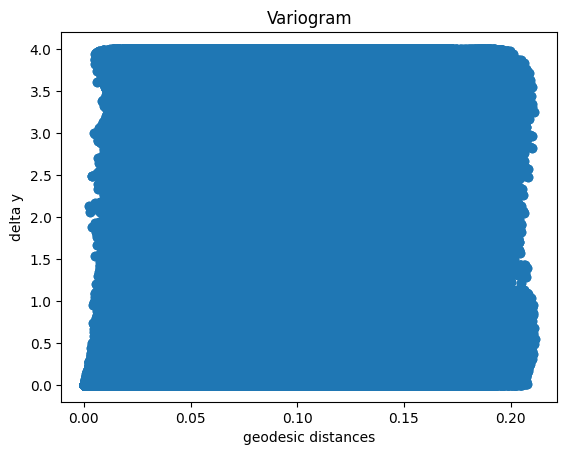

In [7]:
# Calculating the geodesic distance from the original Space

k = 200 #  Adjust as needed
W = kneighbors_graph(X, n_neighbors=k, mode='distance',metric ='euclidean' , include_self=False)

geo_dist_matrix_latent_space, predecessors = shortest_path(W, directed=False, return_predecessors=True)

my_delta_y = np.abs(np.subtract.outer(y,y))

plt.scatter(geo_dist_matrix_latent_space.flatten(),my_delta_y.flatten())
plt.xlabel("geodesic distances")
plt.ylabel("delta y")
plt.title("Variogram")
plt.show()

In [8]:
def construct_mesh_graph_manual(vertices, faces):
    """Build mesh graph from vertices and faces"""
    import networkx as nx
    
    G = nx.Graph()
    
    # Add all vertices
    for i in range(len(vertices)):
        G.add_node(i)
    
    # Add edges from faces
    for face in faces:
        for i in range(3):
            v1, v2 = face[i], face[(i+1) % 3]
            if not G.has_edge(v1, v2):
                # Euclidean distance between connected vertices
                weight = np.linalg.norm(vertices[v1] - vertices[v2])
                G.add_edge(v1, v2, weight=weight)
    
    return G

print("Building full mesh graph...")
full_mesh_graph = construct_mesh_graph_manual(vertices, faces)
print(f"Graph built: {full_mesh_graph.number_of_nodes()} nodes, {full_mesh_graph.number_of_edges()} edges")

# Check connectivity
n_components = nx.number_connected_components(full_mesh_graph)
print(f"Connected components: {n_components}")

Building full mesh graph...
Graph built: 100179 nodes, 301167 edges
Connected components: 1


In [9]:
# print("Computing FULL geodesic distance matrix...")
# print("This will take 30-60 minutes for 100K vertices...")

# n_vertices = len(vertices)
# geo_dist_full = np.full((n_vertices, n_vertices), np.inf, dtype=np.float32)  # Use float32 to save memory

# # Progress tracking
# import time
# start_time = time.time()

# for i in range(n_vertices):
#     if i % 1000 == 0:
#         elapsed = time.time() - start_time
#         if i > 0:
#             est_total = elapsed * n_vertices / i
#             remaining = est_total - elapsed
#             print(f"Vertex {i:6d}/{n_vertices} ({i/n_vertices*100:5.1f}%) - "
#                   f"Elapsed: {elapsed/60:5.1f}min - ETA: {remaining/60:5.1f}min")
    
#     distances_from_i = nx.shortest_path_length(full_mesh_graph, source=i, weight='weight')
#     for j, dist in distances_from_i.items():
#         geo_dist_full[i, j] = dist

# total_time = time.time() - start_time
# print(f"✅ Full geodesic matrix computed in {total_time/60:.1f} minutes")
# print(f"Matrix shape: {geo_dist_full.shape}")
# print(f"Memory usage: {geo_dist_full.nbytes / (1024**3):.1f} GB")

# # Check for disconnected components
# n_inf = np.isinf(geo_dist_full).sum()
# print(f"Infinite distances: {n_inf}")
# if n_inf > 0:
#     print("⚠️  Some vertices are disconnected!")

# # Save the matrix for future use
# print("Saving geodesic matrix...")
# np.save('dragon_geodesic_matrix_full.npy', geo_dist_full)
# print("✅ Matrix saved to 'dragon_geodesic_matrix_full.npy'")

# geo_dist_matrix = geo_dist_full

In [ ]:
# import glob
# import re

# print("Computing FULL geodesic distance matrix with checkpointing...")

# n_vertices = len(vertices)

# # Checkpoint and final file patterns
# checkpoint_pattern = 'dragon_geodesic_matrix_checkpoint_vertex*.npz'
# final_file = 'dragon_geodesic_matrix_full.npy'

# def find_latest_checkpoint():
#     """Find the latest checkpoint file"""
#     checkpoint_files = glob.glob(checkpoint_pattern)
#     if not checkpoint_files:
#         return None, 0
    
#     # Extract vertex numbers from filenames
#     latest_file = None
#     latest_vertex = -1
    
#     for file in checkpoint_files:
#         # Extract vertex number from filename like "..._vertex1234.npz"
#         match = re.search(r'vertex(\d+)\.npz$', file)
#         if match:
#             vertex_num = int(match.group(1))
#             if vertex_num > latest_vertex:
#                 latest_vertex = vertex_num
#                 latest_file = file
    
#     return latest_file, latest_vertex

# def save_checkpoint_safe(vertex_num, matrix, start_time):
#     """Safely save checkpoint with unique filename"""
#     checkpoint_file = f'dragon_geodesic_matrix_checkpoint_vertex{vertex_num}.npz'
#     try:
#         np.savez_compressed(checkpoint_file, 
#                           matrix=matrix, 
#                           last_completed_vertex=vertex_num,
#                           total_vertices=n_vertices,
#                           start_time=start_time)
#         return checkpoint_file
#     except Exception as e:
#         print(f"❌ Error saving checkpoint: {e}")
#         return None

# def cleanup_old_checkpoints(keep_latest=1):
#     """Clean up old checkpoint files, keeping only the latest ones"""
#     checkpoint_files = glob.glob(checkpoint_pattern)
#     if len(checkpoint_files) <= keep_latest:
#         return
    
#     # Sort by vertex number
#     file_vertex_pairs = []
#     for file in checkpoint_files:
#         match = re.search(r'vertex(\d+)\.npz$', file)
#         if match:
#             vertex_num = int(match.group(1))
#             file_vertex_pairs.append((file, vertex_num))
    
#     # Sort by vertex number and keep only the latest
#     file_vertex_pairs.sort(key=lambda x: x[1])
#     files_to_delete = file_vertex_pairs[:-keep_latest]
    
#     for file_to_delete, vertex_num in files_to_delete:
#         try:
#             os.remove(file_to_delete)
#             print(f"🗑️  Cleaned up old checkpoint: vertex {vertex_num}")
#         except:
#             pass

# # Check for existing checkpoint
# latest_checkpoint, latest_vertex = find_latest_checkpoint()
# start_vertex = 0

# if latest_checkpoint:
#     print(f"📁 Found latest checkpoint: {latest_checkpoint}")
#     try:
#         checkpoint_data = np.load(latest_checkpoint)
#         geo_dist_full = checkpoint_data['matrix']
#         start_vertex = int(checkpoint_data['last_completed_vertex']) + 1
#         print(f"🔄 Resuming from vertex {start_vertex}/{n_vertices}")
        
#         # Clean up older checkpoints, keep last 2 for safety
#         cleanup_old_checkpoints(keep_latest=2)
        
#     except Exception as e:
#         print(f"❌ Error loading checkpoint: {e}")
#         print("🆕 Starting fresh computation...")
#         geo_dist_full = np.full((n_vertices, n_vertices), np.inf, dtype=np.float32)
#         start_vertex = 0
# else:
#     print("🆕 No checkpoint found, starting fresh computation...")
#     geo_dist_full = np.full((n_vertices, n_vertices), np.inf, dtype=np.float32)

# # Progress tracking
# start_time = time.time()
# save_interval = 1000  # Save every 1000 vertices

# for i in range(start_vertex, n_vertices):
#     # Progress reporting
#     if i % 1000 == 0 or i == start_vertex:
#         elapsed = time.time() - start_time
#         if i > start_vertex:
#             vertices_processed = i - start_vertex
#             est_total = elapsed * (n_vertices - start_vertex) / vertices_processed
#             remaining = est_total - elapsed
#             print(f"Vertex {i:6d}/{n_vertices} ({i/n_vertices*100:5.1f}%) - "
#                   f"Elapsed: {elapsed/60:5.1f}min - ETA: {remaining/60:5.1f}min")
#         else:
#             print(f"Starting from vertex {i:6d}/{n_vertices}")
    
#     # Compute distances from vertex i
#     distances_from_i = nx.shortest_path_length(full_mesh_graph, source=i, weight='weight')
#     for j, dist in distances_from_i.items():
#         geo_dist_full[i, j] = dist
    
#     # Save checkpoint every save_interval vertices
#     if (i - start_vertex + 1) % save_interval == 0:
#         print(f"💾 Saving checkpoint at vertex {i}...")
#         saved_file = save_checkpoint_safe(i, geo_dist_full, start_time)
#         if saved_file:
#             print(f"✅ Checkpoint saved: {saved_file}")
#             # Clean up old checkpoints, keep last 3 for safety during computation
#             cleanup_old_checkpoints(keep_latest=3)
#         else:
#             print("❌ Failed to save checkpoint")

# # Final save
# total_time = time.time() - start_time
# print(f"✅ Full geodesic matrix computed in {total_time/60:.1f} minutes")
# print(f"Matrix shape: {geo_dist_full.shape}")
# print(f"Memory usage: {geo_dist_full.nbytes / (1024**3):.1f} GB")

# # Check for disconnected components
# n_inf = np.isinf(geo_dist_full).sum()
# print(f"Infinite distances: {n_inf}")
# if n_inf > 0:
#     print("⚠️  Some vertices are disconnected!")

# # Save the final matrix
# print("💾 Saving final geodesic matrix...")
# np.save(final_file, geo_dist_full)
# print(f"✅ Final matrix saved to '{final_file}'")

# # Clean up ALL checkpoint files after successful completion
# print("🗑️  Cleaning up all checkpoint files...")
# checkpoint_files = glob.glob(checkpoint_pattern)
# for checkpoint_file in checkpoint_files:
#     try:
#         os.remove(checkpoint_file)
#         print(f"🗑️  Removed: {checkpoint_file}")
#     except:
#         pass

# geo_dist_matrix = geo_dist_full

Computing FULL geodesic distance matrix with checkpointing...
🆕 No checkpoint found, starting fresh computation...
Starting from vertex      0/100179


In [10]:
import torch
import torch_geometric
from torch_geometric.utils import to_networkx, from_networkx
from torch_geometric.transforms import Distance
import cupy as cp

import time
import os
import glob
import re

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

def networkx_to_torch_geometric_gpu(nx_graph):
    """Convert NetworkX graph to PyTorch Geometric format on GPU"""
    # Convert to PyTorch Geometric
    data = from_networkx(nx_graph, group_edge_attrs=['weight'])
    
    # Move to GPU
    data = data.to(device)
    return data

def compute_shortest_paths_gpu_batch(data, source_vertices, batch_size=100):
    """
    Compute shortest paths from multiple source vertices in batches on GPU
    """
    n_vertices = data.num_nodes
    distances = torch.full((len(source_vertices), n_vertices), 
                          float('inf'), dtype=torch.float32, device=device)
    
    # Process in batches to manage memory
    for batch_start in range(0, len(source_vertices), batch_size):
        batch_end = min(batch_start + batch_size, len(source_vertices))
        batch_sources = source_vertices[batch_start:batch_end]
        
        # Compute shortest paths for this batch
        batch_distances = torch_geometric.utils.shortest_path(
            data.edge_index, 
            data.edge_attr.squeeze() if data.edge_attr is not None else None,
            source=torch.tensor(batch_sources, device=device),
            num_nodes=n_vertices
        )
        
        distances[batch_start:batch_end] = batch_distances
    
    return distances

print("Computing FULL geodesic distance matrix with GPU acceleration...")
print("This should be much faster than CPU version!")

# Convert NetworkX graph to PyTorch Geometric format
print("📊 Converting graph to GPU format...")
data = networkx_to_torch_geometric_gpu(full_mesh_graph)
n_vertices = data.num_nodes

print(f"Graph on GPU: {n_vertices} vertices, {data.num_edges} edges")

# Checkpoint and final file patterns
checkpoint_pattern = 'dragon_geodesic_matrix_checkpoint_vertex*.npz'
final_file = 'dragon_geodesic_matrix_full.npy'

def find_latest_checkpoint():
    """Find the latest checkpoint file"""
    checkpoint_files = glob.glob(checkpoint_pattern)
    if not checkpoint_files:
        return None, 0
    
    latest_file = None
    latest_vertex = -1
    
    for file in checkpoint_files:
        match = re.search(r'vertex(\d+)\.npz$', file)
        if match:
            vertex_num = int(match.group(1))
            if vertex_num > latest_vertex:
                latest_vertex = vertex_num
                latest_file = file
    
    return latest_file, latest_vertex

def save_checkpoint_safe(vertex_num, matrix, start_time):
    """Safely save checkpoint with unique filename"""
    checkpoint_file = f'dragon_geodesic_matrix_checkpoint_vertex{vertex_num}.npz'
    try:
        # Convert GPU tensor to CPU numpy for saving
        if torch.is_tensor(matrix):
            matrix_cpu = matrix.cpu().numpy()
        else:
            matrix_cpu = cp.asnumpy(matrix) if hasattr(matrix, 'device') else matrix
            
        np.savez_compressed(checkpoint_file, 
                          matrix=matrix_cpu, 
                          last_completed_vertex=vertex_num,
                          total_vertices=n_vertices,
                          start_time=start_time)
        return checkpoint_file
    except Exception as e:
        print(f"❌ Error saving checkpoint: {e}")
        return None

def cleanup_old_checkpoints(keep_latest=1):
    """Clean up old checkpoint files"""
    checkpoint_files = glob.glob(checkpoint_pattern)
    if len(checkpoint_files) <= keep_latest:
        return
    
    file_vertex_pairs = []
    for file in checkpoint_files:
        match = re.search(r'vertex(\d+)\.npz$', file)
        if match:
            vertex_num = int(match.group(1))
            file_vertex_pairs.append((file, vertex_num))
    
    file_vertex_pairs.sort(key=lambda x: x[1])
    files_to_delete = file_vertex_pairs[:-keep_latest]
    
    for file_to_delete, vertex_num in files_to_delete:
        try:
            os.remove(file_to_delete)
            print(f"🗑️  Cleaned up old checkpoint: vertex {vertex_num}")
        except:
            pass

# Check for existing checkpoint
latest_checkpoint, latest_vertex = find_latest_checkpoint()
start_vertex = 0

if latest_checkpoint:
    print(f"📁 Found latest checkpoint: {latest_checkpoint}")
    try:
        checkpoint_data = np.load(latest_checkpoint)
        # Load matrix to GPU
        geo_dist_full = torch.tensor(checkpoint_data['matrix'], 
                                   dtype=torch.float32, device=device)
        start_vertex = int(checkpoint_data['last_completed_vertex']) + 1
        print(f"🔄 Resuming from vertex {start_vertex}/{n_vertices}")
        cleanup_old_checkpoints(keep_latest=2)
        
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        print("🆕 Starting fresh computation...")
        geo_dist_full = torch.full((n_vertices, n_vertices), float('inf'), 
                                 dtype=torch.float32, device=device)
        start_vertex = 0
else:
    print("🆕 No checkpoint found, starting fresh computation...")
    geo_dist_full = torch.full((n_vertices, n_vertices), float('inf'), 
                             dtype=torch.float32, device=device)

# Progress tracking
start_time = time.time()
save_interval = 5000  # Increased since GPU is faster
batch_size = 1000     # Process multiple vertices at once

print(f"🚀 Starting GPU computation with batch size {batch_size}")

for batch_start in range(start_vertex, n_vertices, batch_size):
    batch_end = min(batch_start + batch_size, n_vertices)
    current_batch_size = batch_end - batch_start
    
    # Progress reporting
    elapsed = time.time() - start_time
    if batch_start > start_vertex:
        vertices_processed = batch_start - start_vertex
        est_total = elapsed * (n_vertices - start_vertex) / vertices_processed
        remaining = est_total - elapsed
        print(f"Vertices {batch_start:6d}-{batch_end-1:6d}/{n_vertices} "
              f"({batch_start/n_vertices*100:5.1f}%) - "
              f"Elapsed: {elapsed/60:5.1f}min - ETA: {remaining/60:5.1f}min")
    else:
        print(f"Starting batch {batch_start:6d}-{batch_end-1:6d}/{n_vertices}")
    
    # Compute distances for current batch
    try:
        source_vertices = list(range(batch_start, batch_end))
        
        # Use PyTorch Geometric shortest path
        batch_distances = compute_shortest_paths_gpu_batch(
            data, source_vertices, batch_size=min(100, current_batch_size))
        
        # Update the full matrix
        geo_dist_full[batch_start:batch_end] = batch_distances
        
        # Clear GPU cache
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"❌ Error in batch {batch_start}-{batch_end}: {e}")
        print("🔄 Falling back to single vertex computation...")
        
        # Fallback: compute one by one
        for i in range(batch_start, batch_end):
            distances_from_i = torch_geometric.utils.shortest_path(
                data.edge_index, 
                data.edge_attr.squeeze() if data.edge_attr is not None else None,
                source=torch.tensor([i], device=device),
                num_nodes=n_vertices
            )
            geo_dist_full[i] = distances_from_i.squeeze()
    
    # Save checkpoint every save_interval vertices
    if (batch_end - start_vertex) % save_interval < batch_size:
        print(f"💾 Saving checkpoint at vertex {batch_end-1}...")
        saved_file = save_checkpoint_safe(batch_end-1, geo_dist_full, start_time)
        if saved_file:
            print(f"✅ Checkpoint saved: {saved_file}")
            cleanup_old_checkpoints(keep_latest=3)
        else:
            print("❌ Failed to save checkpoint")

# Final save
total_time = time.time() - start_time
print(f"✅ Full geodesic matrix computed in {total_time/60:.1f} minutes")
print(f"Matrix shape: {geo_dist_full.shape}")

# Convert to CPU for final operations
geo_dist_cpu = geo_dist_full.cpu().numpy()
print(f"Memory usage: {geo_dist_cpu.nbytes / (1024**3):.1f} GB")

# Check for disconnected components
n_inf = np.isinf(geo_dist_cpu).sum()
print(f"Infinite distances: {n_inf}")
if n_inf > 0:
    print("⚠️  Some vertices are disconnected!")

# Save the final matrix
print("💾 Saving final geodesic matrix...")
np.save(final_file, geo_dist_cpu)
print(f"✅ Final matrix saved to '{final_file}'")

# Clean up ALL checkpoint files after successful completion
print("🗑️  Cleaning up all checkpoint files...")
checkpoint_files = glob.glob(checkpoint_pattern)
for checkpoint_file in checkpoint_files:
    try:
        os.remove(checkpoint_file)
        print(f"🗑️  Removed: {checkpoint_file}")
    except:
        pass

geo_dist_matrix = geo_dist_cpu

# Clear GPU memory
del geo_dist_full, data
torch.cuda.empty_cache()
print("🧹 GPU memory cleared")

ModuleNotFoundError: No module named 'torch'

# -------------------------------

In [67]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Expected distance matrix: ({X.shape[0]}, {X.shape[0]})")
print(f"Actual distance matrix: {geo_dist_matrix_latent_space.shape}")

X shape: (3000, 3)
y shape: (3000,)
Expected distance matrix: (3000, 3000)
Actual distance matrix: (3000, 3000)


Geodesic distance range: [0.000000, 0.233293]
y value range: [-2.000, 2.000]
Delta y range: [0.000, 4.000]


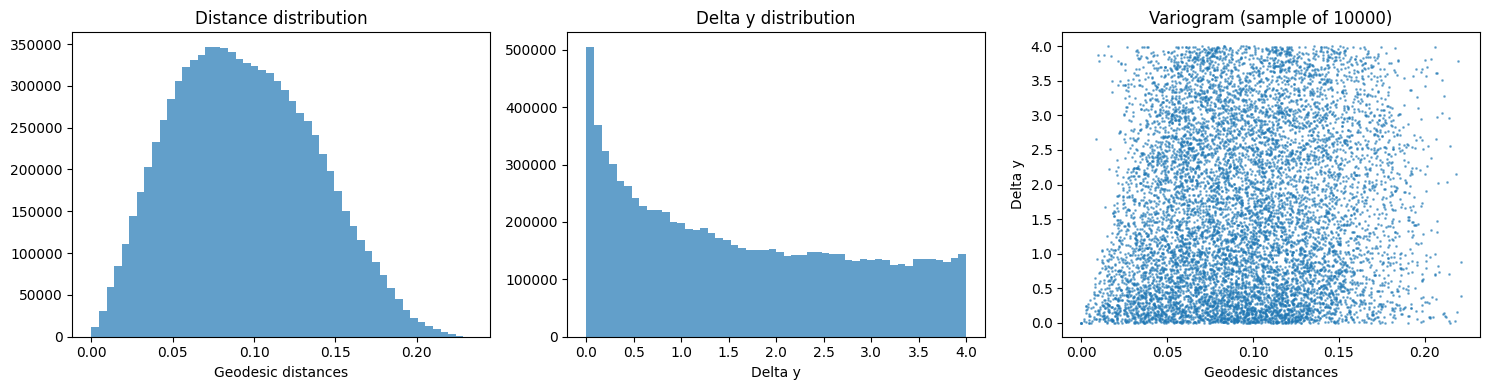

In [68]:
# Look at the distance and y value distributions
print(f"Geodesic distance range: [{geo_dist_matrix_latent_space.min():.6f}, {geo_dist_matrix_latent_space.max():.6f}]")
print(f"y value range: [{y.min():.3f}, {y.max():.3f}]")
print(f"Delta y range: [{my_delta_y.min():.3f}, {my_delta_y.max():.3f}]")

# Plot distributions separately
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distance distribution
axes[0].hist(geo_dist_matrix_latent_space.flatten(), bins=50, alpha=0.7)
axes[0].set_xlabel('Geodesic distances')
axes[0].set_title('Distance distribution')

# Delta y distribution  
axes[1].hist(my_delta_y.flatten(), bins=50, alpha=0.7)
axes[1].set_xlabel('Delta y')
axes[1].set_title('Delta y distribution')

# Variogram with smaller sample for clarity
sample_size = 10000
idx = np.random.choice(len(geo_dist_matrix_latent_space.flatten()), sample_size)
axes[2].scatter(geo_dist_matrix_latent_space.flatten()[idx], 
                my_delta_y.flatten()[idx], alpha=0.5, s=1)
axes[2].set_xlabel('Geodesic distances')
axes[2].set_ylabel('Delta y')
axes[2].set_title(f'Variogram (sample of {sample_size})')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Kernel Matrix Heatmap')

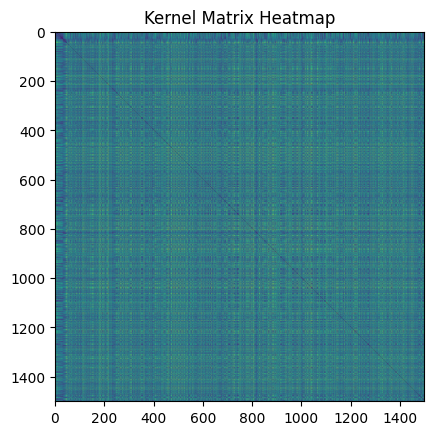

In [45]:
plt.imshow(geo_dist_matrix_latent_space)
plt.title('Kernel Matrix Heatmap')


In [46]:
# # Compute the half squared difference matrix
# my_delta_y2 = 0.5 * (np.subtract.outer(y, y)) ** 2

# # Plot the classical semi-variogram
# plt.scatter(geo_dist_matrix_latent_space.flatten(), my_delta_y2.flatten(), alpha=0.3, s=4)
# plt.xlabel('Geodesic distance (latent space)')
# plt.ylabel(r'$\frac{1}{2}(f(x_i) - f(x_j))^2$')
# plt.title('Empirical semi-variogram')
# plt.show()

# GP Model

In [47]:
#Noise Function
def my_noise(x,hps):
    my_s = np.ones(len(x))*hps[2]
    #noise = np.diag(my_s)
    return my_s

# Mean Function
def my_mean(x,hps):
    mean = np.ones(len(x))*hps[3]
    return mean

In [48]:
def find_indices_ordered(x, x_data):
    matches = (x[:, None, :] == x_data[None, :, :]).all(axis=2)
    
    # Check if all points were found
    found = matches.any(axis=0)
    if not found.all():
        raise ValueError(f"Some points in x_data not found in x")
    
    indices_temp = np.argmax(matches, axis=0)
    return indices_temp


def bump(d, r, ampl):
    """
    evaluates the bump function
    x ... a point (1d numpy array)
    x0 ... 1d numpy array of location of bump function
    returns the bump function b(x,x0) with radius r
    """
    #x_new = x - x0
    #d = np.linalg.norm(x_new, axis = 1)
    a = np.zeros(d.shape)
    a = 1.0 - (d**2/r**2)
    i = np.where(a > 0.0)
    bump = np.zeros(a.shape)
    beta = 0.1
    e = np.exp((-beta/a[i])+beta)
    bump[i] = ampl * e
    return bump

# Precompute x_data_indices once (outside the kernel function)
x_data_indices_global = find_indices_ordered(X, x_train)

def bump_kernel_geodesic_fast(x1, x2, hps):
    """Fast version of bump kernel"""
    # Find indices for x_data in X
    x1_indices = find_indices_ordered(X, x1)
    x2_indices = find_indices_ordered(X, x2)

    # Get geodesic distances (Use precomputed indices)
    d1 = geo_dist_matrix_latent_space[np.ix_(x1_indices, x_data_indices_global)]
    d2 = geo_dist_matrix_latent_space[np.ix_(x2_indices, x_data_indices_global)]
    
    # Compute bump functions
    gs1 = bump(d1, hps[1]/2., 1.).T
    gs2 = bump(d2, hps[1]/2., 1.).T
    
    G = gs1.T @ gs2
    return 2.0 * hps[0] * G/float(len(x_train))

In [52]:
# Defining the bounds of hyperparameter optimization
bounds = np.empty((4,2))
# Kernel Sq Exp 
bounds[0] = np.array([1e-3,100])   # signal variance      
bounds[1] = np.array([1e-2,100])   # kernel length for all input dimensions
# Noise
bounds[2] = np.array([1e-5,100]) 
# Mean
bounds[3] = np.array([np.min(y_train),np.max(y_train)])

init_hps = np.mean(bounds,axis=1)

my_gpo = GPOptimizer(x_train,y_train,
                     init_hyperparameters = init_hps,
                     kernel_function = bump_kernel_geodesic_fast,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                     )

my_gpo.train(hyperparameter_bounds = bounds, init_hyperparameters = init_hps, method='mcmc', max_iter = 4000)

print("GP Training Complete!")

my_gpo.get_hyperparameters()

GP Training Complete!


array([35.24095771,  4.52068641,  0.93894749, -0.38599572])

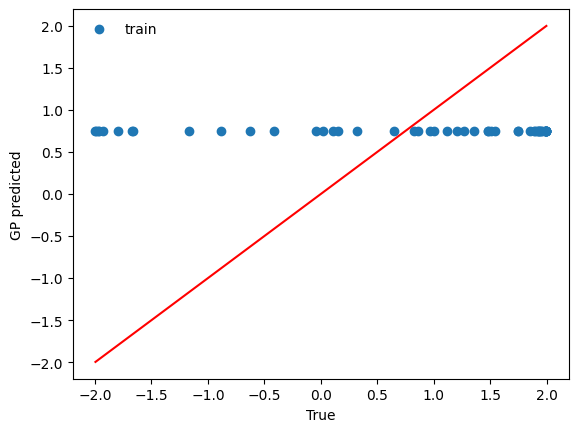

In [53]:
f_train = my_gpo.posterior_mean(x_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

plt.scatter(y_train,f_train,label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 1700.4693298075035 %


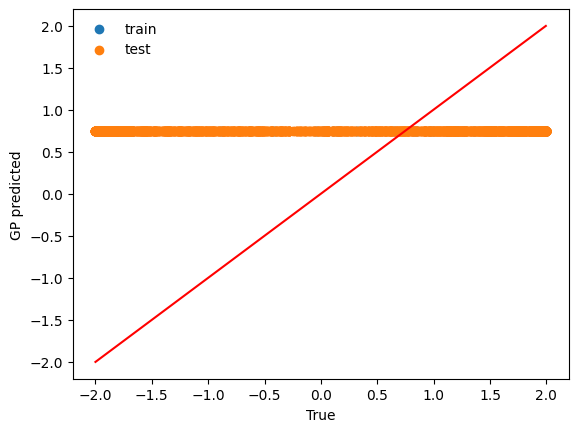

In [54]:

f = my_gpo.posterior_mean(x_test)["m(x)"]

print('RMSE:', my_gpo.rmse(x_test,y_test)*100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_train,f_train,label = 'train')
plt.scatter(y_test,f,label = 'test')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()